# 2.1 二値変数 (Binary Variables)
本ノートブックでは、二値（バイナリ）確率変数のモデル化である**ベルヌーイ分布 (Bernoulli distribution)**、**二項分布 (Binomial distribution)**、そしてベイズ推論のための共役事前分布である**ベータ分布 (Beta distribution)** について理論と実装の両面から詳しく学びます。

## 2.1.1 ベルヌーイ分布と最尤推定

1回の試行で2つの結果（表/裏、成功/失敗、0/1）のいずれかをとる確率変数 $x \in \{0, 1\}$ を考えます。
パラメータ $\mu \in [0, 1]$ を $x=1$ となる確率とすると、$p(x=1|\mu) = \mu$, $p(x=0|\mu) = 1 - \mu$ です。
これを1つの数式で表現したものが**ベルヌーイ分布 (Bernoulli distribution)** です。

$$ \mathrm{Bern}(x | \mu) = \mu^x (1 - \mu)^{1 - x} $$

### 期待値と分散
- 期待値: $\mathbb{E}[x] = 1 \cdot \mu + 0 \cdot (1 - \mu) = \mu$
- 分散: $\mathrm{var}[x] = \mathbb{E}[x^2] - \mathbb{E}[x]^2 = \mu - \mu^2 = \mu(1 - \mu)$

### 最尤推定 (Maximum Likelihood Estimation)
観測データセット $\mathcal{D} = \{x_1, x_2, \dots, x_N\}$ が独立同分布 (i.i.d.) で得られたと仮定すると、尤度関数は以下のようになります。

$$ p(\mathcal{D} | \mu) = \prod_{n=1}^N p(x_n | \mu) = \prod_{n=1}^N \mu^{x_n} (1 - \mu)^{1 - x_n} $$

対数尤度関数 $\ln p(\mathcal{D} | \mu)$ を最大化します。
$$ \ln p(\mathcal{D} | \mu) = \sum_{n=1}^N \{ x_n \ln \mu + (1 - x_n) \ln (1 - \mu) \} $$

$\mu$ について微分して 0 と置きます。
$$ \frac{\partial \ln p}{\partial \mu} = \sum_{n=1}^N \left( \frac{x_n}{\mu} - \frac{1 - x_n}{1 - \mu} \right) = 0 $$

表（$x=1$）が出た回数を $m = \sum_{n=1}^N x_n$ と置くと、最尤推定量 $\mu_{\mathrm{ML}}$ は以下のように求まります。

$$ \mu_{\mathrm{ML}} = \frac{m}{N} $$

これは直感的な標本平均と完全に一致します。

### 最尤推定の過学習（ゼロ頻度問題）
データ数が少ない場合、例えばコインを3回投げて3回とも表が出た場合（$N=3, m=3$）、最尤推定は $\mu_{\mathrm{ML}} = 1.0$ と予測します。
これにより、次に裏が出る確率は厳密に 0 と予測されてしまい、これは過学習の典型例です。この問題を解決するのが**ベイズ的アプローチ**です。

## 2.1.2 二項分布 (Binomial Distribution)

サイズ $N$ のデータセットにおいて、$x=1$ となる回数 $m$ の確率分布は**二項分布 (Binomial distribution)** で与えられます。

$$ \mathrm{Bin}(m | N, \mu) = \binom{N}{m} \mu^m (1 - \mu)^{N - m} $$

ここで $\binom{N}{m} = \frac{N!}{m!(N-m)!}$ は二項係数です。
二項分布の平均と分散は、独立な $N$ 個のベルヌーイ変数の和であることから直ちに求まります。
$$ \mathbb{E}[m] = N\mu, \quad \mathrm{var}[m] = N\mu(1 - \mu) $$

## 2.1.3 ベータ分布 (The Beta Distribution)

ベイズ推論を行うために、パラメータ $\mu$ に対する事前分布 $p(\mu)$ を導入します。
二項尤度 $\mu^m (1-\mu)^{N-m}$ に対して、事後分布が事前分布と同じ関数形となる**共役事前分布 (conjugate prior)** として**ベータ分布**が選ばれます。

$$ \mathrm{Beta}(\mu | a, b) = \frac{\Gamma(a + b)}{\Gamma(a)\Gamma(b)} \mu^{a - 1} (1 - \mu)^{b - 1} $$

ここで $\Gamma(x)$ はガンマ関数です。$a, b$ は事前分布の形状を制御する**ハイパーパラメータ (hyperparameters)** です。

### 平均と分散
$$ \mathbb{E}[\mu] = \frac{a}{a + b} $$
$$ \mathrm{var}[\mu] = \frac{ab}{(a + b)^2 (a + b + 1)} $$

### 事後分布の計算 (ベイズの更新)
観測データ（表が $m$ 回、裏が $l = N - m$ 回）が得られたときの事後分布 $p(\mu | m, l, a, b)$ は、尤度と事前分布の積に比例します。

$$ p(\mu | m, l, a, b) \propto p(m | N, \mu) p(\mu | a, b) \propto \mu^{m + a - 1} (1 - \mu)^{l + b - 1} $$

規格化定数を考慮すると、事後分布も再びベータ分布となります！
$$ p(\mu | m, l, a, b) = \mathrm{Beta}(\mu | a + m, b + l) $$

この式から、ハイパーパラメータ $a, b$ は、あたかも「事前に行った仮想的な試行において、$x=1$ が $a-1$ 回、$x=0$ が $b-1$ 回観測された」かのような**有効観測数 (effective number of observations)** として解釈できます。

### 逐次ベイズ更新 (Sequential Learning)
ベイズ推論では、1つの観測データが得られるたびに事後分布を更新できます。
前のステップの事後分布が、次のステップの事前分布として自然に機能します。

Plot saved to: result/fig2_2_beta_priors.png


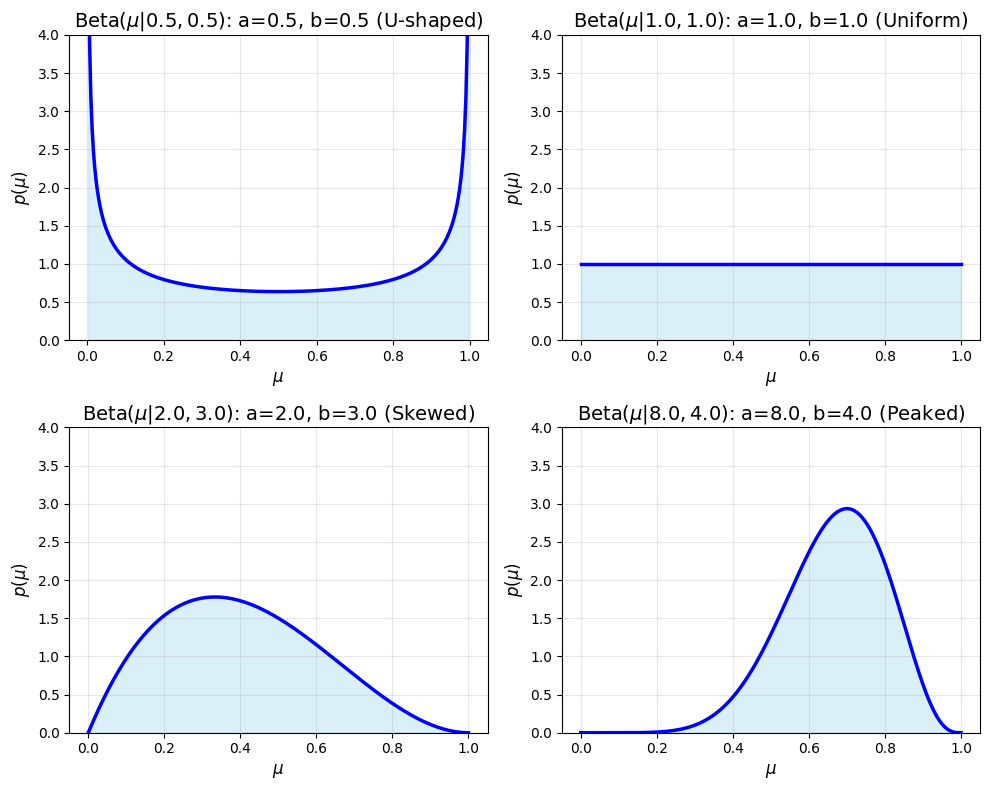

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 2.2 の再現: 様々なハイパーパラメータ (a, b) に対するベータ分布のプロット
mu = np.linspace(0, 1, 300)
params = [
    (0.5, 0.5, 'a=0.5, b=0.5 (U-shaped)'),
    (1.0, 1.0, 'a=1.0, b=1.0 (Uniform)'),
    (2.0, 3.0, 'a=2.0, b=3.0 (Skewed)'),
    (8.0, 4.0, 'a=8.0, b=4.0 (Peaked)')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (a, b, title) in zip(axes.flat, params):
    pdf = stats.beta.pdf(mu, a, b)
    ax.plot(mu, pdf, 'b-', lw=2.5)
    ax.fill_between(mu, 0, pdf, color='skyblue', alpha=0.3)
    ax.set_title(f'Beta($\mu|{a}, {b}$): {title}')
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$p(\mu)$')
    ax.set_ylim(0, 4)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig2_2_beta_priors.png')
plt.show()

## 2.1.4 逐次ベイズ学習の実装と可視化

PRML Figure 2.3 の実験を再現します。
真のパラメータ $\mu = 0.7$ のコイン投げデータを逐次的に生成し、事前分布 $\mathrm{Beta}(\mu | 2, 2)$ から観測データ（表 $x=1$ または裏 $x=0$）を取り込むたびに事後分布がどのように更新されていくかを可視化します。

Plot saved to: result/fig2_3_bayesian_sequential_learning.png


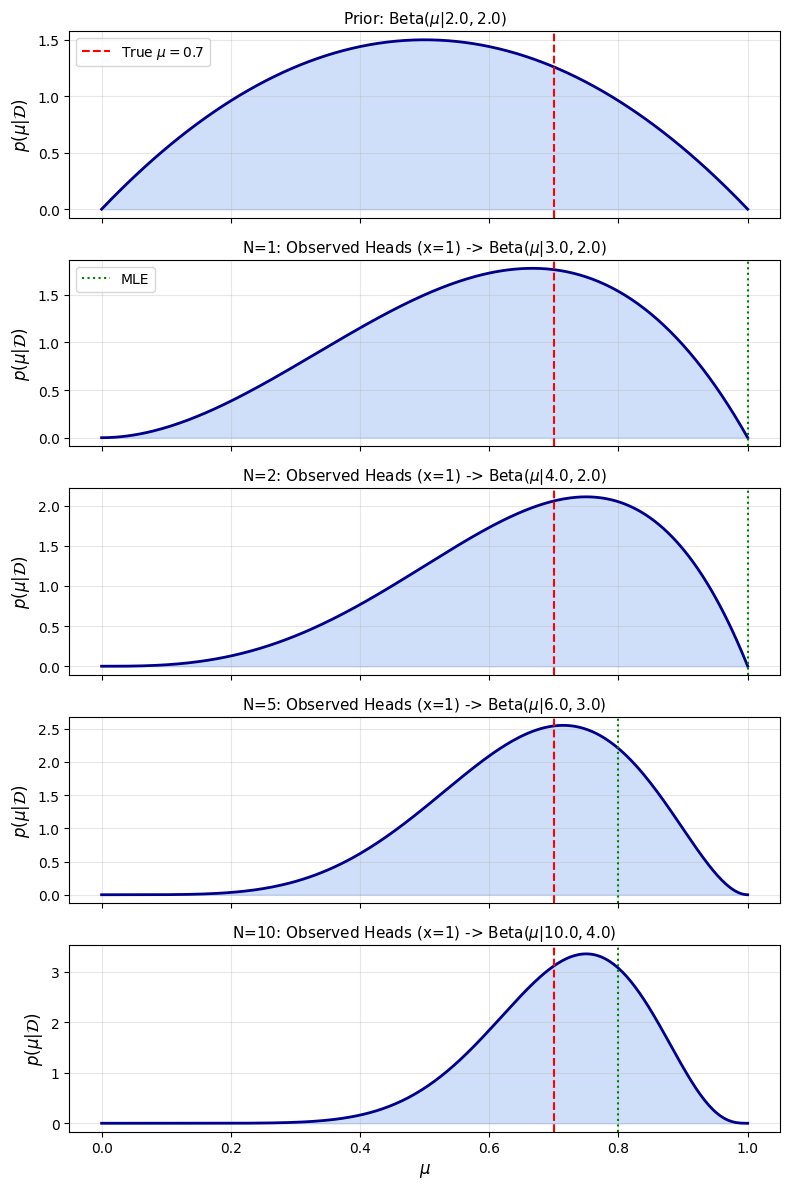

In [2]:
# 逐次ベイズ学習のシミュレーション
np.random.seed(42)
true_mu = 0.7

# 観測シーケンス（表: 1, 裏: 0）
observations = [1, 1, 0, 1, 1, 1, 0, 1, 1, 1]

steps_to_plot = [0, 1, 2, 5, 10]
a_0, b_0 = 2.0, 2.0  # 初期の事前分布

fig, axes = plt.subplots(len(steps_to_plot), 1, figsize=(8, 12), sharex=True)

for i, n_obs in enumerate(steps_to_plot):
    ax = axes[i]
    if n_obs == 0:
        a_curr, b_curr = a_0, b_0
        title = f'Prior: Beta($\mu|{a_curr:.1f}, {b_curr:.1f}$)'
    else:
        obs_sub = observations[:n_obs]
        m = sum(obs_sub)
        l = n_obs - m
        a_curr = a_0 + m
        b_curr = b_0 + l
        last_obs = observations[n_obs - 1]
        obs_type = "Heads (x=1)" if last_obs == 1 else "Tails (x=0)"
        title = f'N={n_obs}: Observed {obs_type} -> Beta($\mu|{a_curr:.1f}, {b_curr:.1f}$)'
    
    pdf = stats.beta.pdf(mu, a_curr, b_curr)
    ax.plot(mu, pdf, 'darkblue', lw=2)
    ax.fill_between(mu, 0, pdf, color='cornflowerblue', alpha=0.3)
    ax.axvline(true_mu, color='red', linestyle='--', lw=1.5, label='True $\mu=0.7$' if i == 0 else "")
    
    # 最尤推定値（m/N）
    if n_obs > 0:
        mle = m / n_obs
        ax.axvline(mle, color='green', linestyle=':', lw=1.5, label='MLE' if i == 1 else "")
    
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(r'$p(\mu|\mathcal{D})$')
    ax.grid(True, alpha=0.3)
    if i == 0 or i == 1:
        ax.legend(loc='upper left')

axes[-1].set_xlabel(r'$\mu$')
plt.tight_layout()
save_plot(fig, 'result', 'fig2_3_bayesian_sequential_learning.png')
plt.show()

## 2.1.5 事後予測分布 (Posterior Predictive Distribution)

ベイズ推論の目的は、単にパラメータ $\mu$ の分布を求めるだけでなく、**次の新しい観測値 $x_{\mathrm{new}}$ を予測すること**です。
パラメータ $\mu$ の不確実性を積分消去（周辺化）することにより、予測分布が得られます。

$$ p(x_{\mathrm{new}} = 1 | \mathcal{D}) = \int_0^1 p(x_{\mathrm{new}} = 1 | \mu) p(\mu | \mathcal{D}) d\mu = \int_0^1 \mu \, \mathrm{Beta}(\mu | a_N, b_N) d\mu = \mathbb{E}[\mu | \mathcal{D}] $$

ベータ分布の期待値公式より、
$$ p(x_{\mathrm{new}} = 1 | \mathcal{D}) = \frac{a + m}{a + m + b + l} $$

- サンプル数が極めて少ないとき（$m = l = 0$）: $p(x_{\mathrm{new}} = 1) = \frac{a}{a+b}$ （事前分布の平均）
- サンプル数が無限大のとき（$N = m + l \to \infty$）: $p(x_{\mathrm{new}} = 1) \to \frac{m}{N} = \mu_{\mathrm{ML}}$ （最尤推定値に一致）

このように、ベイズ推論はデータ数が少ないときは事前知識で過学習を防ぎ、データ数が増えると客観的なデータ駆動の推定へと自然に滑らかに移行します。